In [41]:
import numpy as np
import pandas as pd
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima 

In [42]:
df = pd.read_excel(
    "/home/henrique/ic-rodrigo/Controle_Faturamento_2023.xlsx",
    sheet_name="Consumo Médio - Clientes",
)

df.drop(df.iloc[:, 48:68], inplace=True, axis=1)
df.drop("Nº Cliente", inplace=True, axis=1)
df.drop("Cliente", inplace=True, axis=1)

df = df.head()

df1 = df.transpose()
df = df1.rename(columns=df1.iloc[0])
df.drop("UC", inplace=True, axis=0)
df.dropna(inplace=True)

df.index
dates = np.array(df.index, dtype="datetime64[D]")
idx = pd.DatetimeIndex(dates)
df["idx"] = idx
df.set_index("idx", inplace=True)
df.index.freq = "MS"
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,1549.0,7440.0,760.0,1040.0,1680.0
2019-10-01,2045.0,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [43]:
df[3003858507].iloc[3:5] = np.nan
df[3003858507].iloc[17] = np.nan
df[3003858507].iloc[23:25] = np.nan
df[3003858507].iloc[41] = np.nan
df

,3003858507,3001084033,3011373971,3001449459,3011504476
idx,,,,,
2019-06-01,1246.0,7160.0,440.0,960.0,1560.0
2019-07-01,1081.0,6520.0,600.0,920.0,1280.0
2019-08-01,1184.0,6840.0,680.0,1120.0,1360.0
2019-09-01,NaN,7440.0,760.0,1040.0,1680.0
2019-10-01,NaN,6920.0,560.0,1120.0,1680.0
2019-11-01,4017.0,6920.0,520.0,1240.0,2920.0
2019-12-01,2386.0,7240.0,320.0,1000.0,1960.0
2020-01-01,4239.0,6560.0,440.0,1120.0,2280.0
2020-02-01,2854.0,7440.0,280.0,1200.0,2480.0


In [44]:
df[3003858507] = df[3003858507].fillna(method="backfill", axis=None)

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

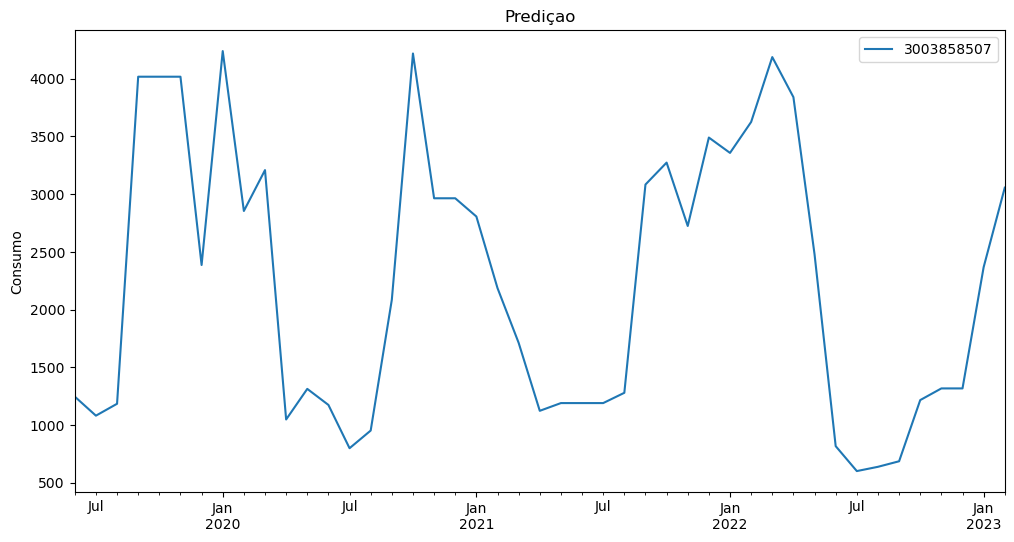

In [45]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)

In [46]:
train = df.iloc[:40]
test = df.iloc[40:]

test = test.astype(float)
train = train.astype(float)

model = SARIMAX(df[3003858507].astype(float), order=(1, 0, 0), seasonal_order=(5, 1, 10, 12))
results = model.fit();

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           17     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.08413D+00    |proj g|=  2.76607D-01


 This problem is unconstrained.



At iterate    5    f=  5.99677D+00    |proj g|=  1.51778D-02

At iterate   10    f=  5.99586D+00    |proj g|=  3.48155D-04

At iterate   15    f=  5.99584D+00    |proj g|=  1.25797D-03

At iterate   20    f=  5.99582D+00    |proj g|=  4.19312D-04

At iterate   25    f=  5.99580D+00    |proj g|=  3.04992D-03

At iterate   30    f=  5.99475D+00    |proj g|=  1.67517D-02

At iterate   35    f=  5.99129D+00    |proj g|=  1.65290D-02

At iterate   40    f=  5.97281D+00    |proj g|=  7.72941D-02

At iterate   45    f=  5.94358D+00    |proj g|=  5.43155D-02
  ys=-7.549E-03  -gs= 8.274E-03 BFGS update SKIPPED



   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   17     46     66      1     1     0   5.416D-02   5.944D+00
  F =   5.9435843082709585     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


In [47]:
start = len(train)
end = len(train) + len(test) - 1
predictions = results.predict(
    start=0, end=end, dynamic=False, typ="levels"
).rename("SARIMA Predictions")

future_predictions = results.predict(
    start=end, end=end + 48, dynamic=False, typ="levels"
).rename("SARIMA Future Predictions")

mean_error = []

for i in range(len(predictions)):
    error_value = np.abs((predictions[i]-df[3003858507][i])/(df[3003858507][i]))*100
    mean_error.append(error_value)
    print(
        f"predição={predictions[i]}, esperado={df[3003858507][i]}, erro={np.abs((predictions[i]-df[3003858507][i])/(df[3003858507][i]))*100}%"
    )

aux = 0

for i in range(len(mean_error)):
   aux = mean_error[i] + aux

final_mean = aux/len(mean_error)

print(f"Erro percentual médio = {final_mean}%")

predição=0.0, esperado=1246.0, erro=100.0%
predição=198.48879947946756, esperado=1081.0, erro=81.6384089288189%
predição=203.34204884644805, esperado=1184.0, erro=82.82584046905%
predição=219.9990503509132, esperado=4017.0, erro=94.5232997174281%
predição=660.7690362601251, esperado=4017.0, erro=83.55068368782362%
predição=741.0049664678221, esperado=4017.0, erro=81.5532744220109%
predição=755.3995506783507, esperado=2386.0, erro=68.34033735631388%
predição=505.32581229849217, esperado=4239.0, erro=88.07912686250313%
predição=744.1002185731483, esperado=2854.0, erro=73.92781294417841%
predição=567.6526834840271, esperado=3208.0, erro=82.30509091383956%
predição=572.2546550614347, esperado=1048.0, erro=45.395548181160805%
predição=185.8720779093398, esperado=1313.0, erro=85.843710745671%
predição=1232.7195526463195, esperado=1174.0, erro=5.001665472429257%
predição=857.1789335424083, esperado=799.0, erro=7.28146852846162%
predição=795.0062537450452, esperado=952.0, erro=16.4909397326633

[Text(0.5, 0, ''), Text(0, 0.5, 'Consumo')]

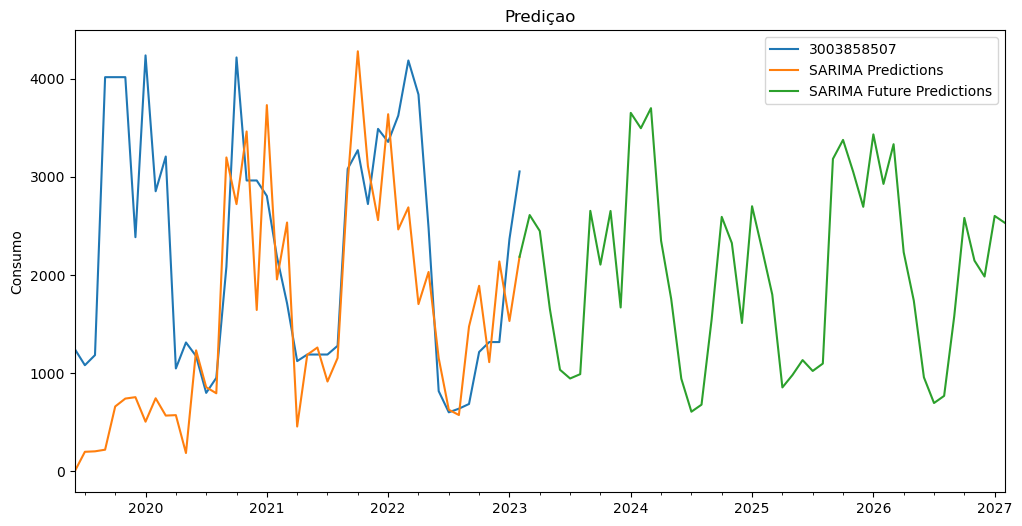

In [48]:
title = "Prediçao"
ylabel = "Consumo"
xlabel = ""

ax = df[3003858507].plot(legend=True, figsize=(12, 6), title=title)
predictions.plot(legend=True)
future_predictions.plot(legend=True)
ax.autoscale(axis="x", tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)